# Redes Convolucionales con PyTorch

En este actividad se implementarán 3 modelos que usen una red neuronal convolucional usando PyTorch para el conjunto de datos CIFAR-10. Se evaluarán los tres modelos y se elegirá el mejor de los tres. 

Nota: Se usó apoyo de la inteligencia artificial para implementar buenas prácticas y desplegar algunas salidas.

In [25]:
# Imports

import random
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import numpy as np

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [27]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_path = "./data/" if IN_COLAB else "./data/cifar_10"

## Cargar conjunto de datos

In [28]:
# Se definen transformaciones para convertir las imagenes a tensores y paa aplicar normalización para mejorar el entrenamiento
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),  # mean
                         (0.5, 0.5, 0.5))  # std
])

In [29]:
# Cargar el dataset (entrenamiento y prueba)
train_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
    transform=transform
)

In [30]:
# Implementar DataLoader para los batches
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [31]:
# Verificar clases de salida para clasificación
classes = train_dataset.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [32]:
# Verificar dimensiones de los datos (entradas y salidas)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


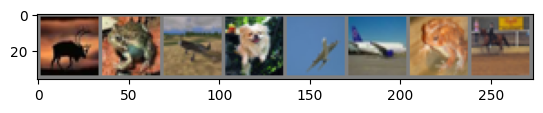

['deer', 'frog', 'airplane', 'dog', 'airplane', 'airplane', 'frog', 'horse']


In [ ]:
# Visualizar imágenes aleatorias de ejemplo del dataset
def imshow(img):
    img = img / 2 + 0.5  # desnormalizar
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

num_images = 8
indices = random.sample(range(len(train_dataset)), num_images)

images = [train_dataset[i][0] for i in indices]
labels = [train_dataset[i][1] for i in indices]

images_tensor = torch.stack(images)

imshow(torchvision.utils.make_grid(images_tensor))
print([classes[label] for label in labels])

## Definir 3 Redes Neuronales Convolucionales